<a href="https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/AI_ExperimentalPhysics/MomentOfInertiaEigenvalues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total mass M = 15.000
Center of mass: [0. 0. 0.]

Inertia tensor I (about CM):
[[29. -3. -0.]
 [-3. 31. -0.]
 [-0. -0. 12.]]

Principal moments of inertia (eigenvalues of I):
[12.         26.83772234 33.16227766]

Principal axes (columns of eigvecs_I):
[[ 0.         -0.81124219 -0.58471028]
 [ 0.         -0.58471028  0.81124219]
 [ 1.         -0.          0.        ]]

Mass-weighted covariance matrix C:
[[0.46666667 0.2        0.        ]
 [0.2        0.33333333 0.        ]
 [0.         0.         1.6       ]]

PCA eigenvalues (variance along principal directions):
[0.18918149 0.61081851 1.6       ]

PCA eigenvectors (columns of eigvecs_C):
[[ 0.58471028 -0.81124219  0.        ]
 [-0.81124219 -0.58471028  0.        ]
 [ 0.         -0.          1.        ]]
------- eigvecs_I.T ----------
[[ 0.          0.          1.        ]
 [-0.81124219 -0.58471028 -0.        ]
 [-0.58471028  0.81124219  0.        ]]
------- eigvecs_C ------------
[[ 0.58471028 -0.81124219  0.        ]
 [-0.81124219 

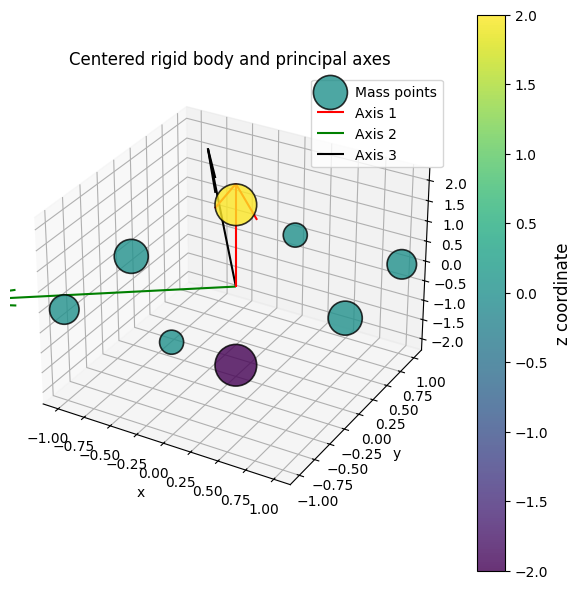

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Define a synthetic rigid body: 8 point masses in 3D
# ------------------------------------------------------------
# Columns: x, y, z, mass
data = np.array([
    [ 1.0,  0.0,  0.0, 2.0],   # P1
    [-1.0,  0.0,  0.0, 2.0],   # P2
    [ 0.0,  1.0,  0.0, 1.0],   # P3
    [ 0.0, -1.0,  0.0, 1.0],   # P4
    [ 0.0,  0.0,  2.0, 3.0],   # P5
    [ 0.0,  0.0, -2.0, 3.0],   # P6
    [ 1.0,  1.0,  0.0, 1.5],   # P7
    [-1.0, -1.0,  0.0, 1.5],   # P8
])

coords = data[:, :3]   # (N, 3)
masses = data[:, 3]    # (N,)

N = coords.shape[0]
M = masses.sum()

print(f"Total mass M = {M:.3f}")

# ------------------------------------------------------------
# 2. Center of mass and centered coordinates
# ------------------------------------------------------------
R_cm = (masses[:, None] * coords).sum(axis=0) / M
coords_c = coords - R_cm  # centered coordinates

print("Center of mass:", R_cm)

# ------------------------------------------------------------
# 3. Inertia tensor about CM
# ------------------------------------------------------------
x = coords_c[:, 0]
y = coords_c[:, 1]
z = coords_c[:, 2]

I_xx = np.sum(masses * (y**2 + z**2))
I_yy = np.sum(masses * (x**2 + z**2))
I_zz = np.sum(masses * (x**2 + y**2))

I_xy = -np.sum(masses * x * y)
I_xz = -np.sum(masses * x * z)
I_yz = -np.sum(masses * y * z)

I = np.array([
    [I_xx, I_xy, I_xz],
    [I_xy, I_yy, I_yz],
    [I_xz, I_yz, I_zz]
])

print("\nInertia tensor I (about CM):")
print(I)

# Eigen-decomposition of inertia tensor
eigvals_I, eigvecs_I = np.linalg.eigh(I)  # symmetric → eigh

print("\nPrincipal moments of inertia (eigenvalues of I):")
print(eigvals_I)
print("\nPrincipal axes (columns of eigvecs_I):")
print(eigvecs_I)

# ------------------------------------------------------------
# 4. Mass-weighted covariance matrix and PCA
# ------------------------------------------------------------
# Mass-weighted covariance:
# C = (1/M) * sum_i m_i * r_i r_i^T  (with r_i centered)
C = np.zeros((3, 3))
for i in range(N):
    r = coords_c[i, :][:, None]  # column vector
    C += masses[i] * (r @ r.T)
C /= M
'''
coords_c[i, :] is a 1‑D array of shape (3,).
coords_c[i, :][:, None] is a column vector of shape (3,1).

You need the column‑vector form to compute the outer product
𝑟@ r.T using the @ operator.
'''


print("\nMass-weighted covariance matrix C:")
print(C)

eigvals_C, eigvecs_C = np.linalg.eigh(C)

print("\nPCA eigenvalues (variance along principal directions):")
print(eigvals_C)
print("\nPCA eigenvectors (columns of eigvecs_C):")
print(eigvecs_C)
'''
Eigenvectors of the C matrix is exactrly the definiiton of PCA
'''

# ------------------------------------------------------------
# 5. Compare eigenvectors: same rotation (up to sign/order)
# ------------------------------------------------------------
# We check alignment by absolute dot products between eigenvectors.
print ('------- eigvecs_I.T ----------')
print (eigvecs_I.T)
print ('------- eigvecs_C ------------')
print (eigvecs_C)
alignment = np.abs(eigvecs_I.T @ eigvecs_C)
print("\nAlignment matrix |e_I^T e_C| (should be close to a permutation of identity):")
print(alignment)
'''
PCA finds directions of maximum spread of mass.
The inertia tensor finds directions of minimum resistance to rotation.
Both depend on the same quadratic form 𝑟 𝑟_T
Therefore, they must share the same principal axes.
'''

# ------------------------------------------------------------
# 6. Relationship between eigenvalues of I and C
# ------------------------------------------------------------
# For a rigid body, I and C share eigenvectors and eigenvalues are related.
# In principal-axis basis, I_k = sum_i m_i r_i^2 - sum_i m_i r_{k,i}^2
# while C_k = (1/M) sum_i m_i r_{k,i}^2.
# So I_k = M * (R2_mean - C_k), where R2_mean = (1/M) sum_i m_i r_i^2.

r2 = (coords_c**2).sum(axis=1)
R2_mean = np.sum(masses * r2) / M

print("\nMean squared radius R2_mean =", R2_mean)

I_from_C = M * (R2_mean - eigvals_C)
print("\nPrincipal moments of inertia reconstructed from C eigenvalues:")
print(I_from_C)
print("\nDifference (I_from_C - eigvals_I):")
print(I_from_C - eigvals_I)

# ------------------------------------------------------------
# 7. Simple visualization: point cloud + principal axes
# ------------------------------------------------------------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

sizes = 300 * masses              # area proportional to mass
colors = coords_c[:, 2]           # color = z coordinate

ax.scatter(
    coords_c[:, 0],
    coords_c[:, 1],
    coords_c[:, 2],
    s=sizes,
    c=colors,
    cmap='viridis',               # or 'plasma', 'coolwarm', 'turbo'
    alpha=0.8,
    edgecolor='black',
    linewidth=1.2,
    label='Mass points'
)

cb = plt.colorbar(ax.collections[0], ax=ax)
cb.set_label("z coordinate", fontsize=12)


# Plot principal axes from inertia tensor (same as PCA)
origin = np.array([[0, 0, 0]])
scale = 2.5

for k in range(3):
    v = eigvecs_I[:, k]
    ax.quiver(origin[0, 0], origin[0, 1], origin[0, 2],
              scale * v[0], scale * v[1], scale * v[2],
              color=['r', 'g', 'k'][k],
              label=f'Axis {k+1}')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Centered rigid body and principal axes')
ax.legend()
plt.tight_layout()
plt.show()
